### 1.Importing the Library

In [76]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

### 2. Loading the Dataset

#### 2.1 Training Dataset

In [77]:
# Training Dataset
train_path = r".\datasets\train.csv";
df_train = pd.read_csv(train_path);
df_train.head()

,Year,dengue_total,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,daily_rain_density,average_humidity,avg_soil_moisture,avg_soil_temperature,avg_snowfall,avg_precipitation
0,2024,0,KALIKOT,May,10.223880,19.783870,88.951584,0.418761,10.755308,0.000000,19.783870,high,extreme,high,low,none,high
1,2022,0,PARSA,Feb,30.428612,6.673333,62.701965,0.234122,28.814114,0.000000,6.673333,moderate,high,moderate,high,none,moderate
2,2024,19,SALYAN,Sep,10.010685,0.100000,70.479485,0.319492,11.226091,0.000000,0.100000,low,high,high,low,none,low
3,2022,1,BAJHANG,Jan,-6.802581,0.000000,34.566444,0.366226,-1.123817,0.388387,0.551613,no,low,high,low,light,low
4,2022,0,KALIKOT,May,10.058961,13.132258,89.504610,0.415793,10.209129,0.000000,13.132258,high,extreme,high,low,none,high


#### 2.2 Testing Dataset

In [78]:
test_path = r".\datasets\test.csv";
df_test = pd.read_csv(test_path);
df_test.head();

#### 2.3 Validation Dataset

In [79]:
val_path = r".\datasets\val.csv";
df_val = pd.read_csv(val_path);
df_val.head()

,Year,dengue_total,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,daily_rain_density,average_humidity,avg_soil_moisture,avg_soil_temperature,avg_snowfall,avg_precipitation
0,2023,2,SANKHUWASABHA,Dec,10.692419,2.193548,62.936783,0.239148,11.303670,0.0,2.193548,low,high,moderate,low,none,low
1,2023,0,SIRAHA,Dec,28.076279,8.280644,83.651380,0.388021,28.989265,0.0,8.280644,moderate,extreme,high,high,none,moderate
2,2023,1,SARLAHI,Feb,28.192223,10.076666,84.941230,0.381857,29.020670,0.0,10.076666,high,extreme,high,high,none,high
3,2024,3,RUPANDEHI,Jan,14.279301,1.061290,84.866560,0.317665,16.197376,0.0,1.061290,low,extreme,high,moderate,none,low
4,2023,0,TAPLEJUNG,Mar,11.096197,21.135487,90.306070,0.422427,9.387677,0.0,21.135487,high,extreme,high,low,none,high


### 3. Data Exploration

#### 3.1 Training Dataset Exploraition

In [80]:

# checking the total amount of data
print(f"The total amount of training data is {len(df_train)}");

# checking the data types of each features
df_train.info()

# Checking the shape of train data
df_train.shape


The total amount of training data is 62596
<class 'pandas.DataFrame'>
RangeIndex: 62596 entries, 0 to 62595
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        62596 non-null  int64  
 1   dengue_total                62596 non-null  int64  
 2   Location                    62596 non-null  str    
 3   Month                       62596 non-null  str    
 4   monthly_avg_temperature     62596 non-null  float64
 5   avg_daily_rain              62596 non-null  float64
 6   avg_daily_humidity          62596 non-null  float64
 7   avg_daily_soil_moisture     62596 non-null  float64
 8   avg_daily_soil_temperature  62596 non-null  float64
 9   avg_daily_snowfall          62596 non-null  float64
 10  avg_daily_precipitation     62596 non-null  float64
 11  daily_rain_density          62596 non-null  str    
 12  average_humidity            62596 non-null  str    
 13 

(62596, 17)

In [81]:
# summarizes only numeric columns
print(df_train.describe())
# returns the number of duplicate rows in the DataFrame
df_train.duplicated().sum()

               Year  dengue_total  monthly_avg_temperature  avg_daily_rain  \
count  62596.000000  62596.000000             62596.000000    62596.000000   
mean    2023.001502     51.835581                15.797268        4.755448   
std        0.816847    359.301590                 9.408848        6.042926   
min     2022.000000      0.000000               -16.712560        0.000000   
25%     2022.000000      0.000000                10.387795        0.190323   
50%     2023.000000      2.000000                17.289791        1.885714   
75%     2024.000000     11.000000                22.695229        7.896666   
max     2024.000000   9891.000000                32.659233       35.351612   

       avg_daily_humidity  avg_daily_soil_moisture  \
count        62596.000000             62596.000000   
mean            71.380446                 0.315917   
std             14.497634                 0.078159   
min             10.414664                 0.025777   
25%             62.092870  

np.int64(0)

In [82]:
# Checking for the null values
print(df_train.isnull().sum())

Year                          0
dengue_total                  0
Location                      0
Month                         0
monthly_avg_temperature       0
avg_daily_rain                0
avg_daily_humidity            0
avg_daily_soil_moisture       0
avg_daily_soil_temperature    0
avg_daily_snowfall            0
avg_daily_precipitation       0
daily_rain_density            0
average_humidity              0
avg_soil_moisture             0
avg_soil_temperature          0
avg_snowfall                  0
avg_precipitation             0
dtype: int64


#### 3.2 Testing Dataset Exploration

In [83]:
# checking the total amount of data
print(f"The total amount of testing data is {len(df_test)}");

# checking the data types of each features
df_test.info()
# Checking the shape of test data
df_test.shape

The total amount of testing data is 13415
<class 'pandas.DataFrame'>
RangeIndex: 13415 entries, 0 to 13414
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        13415 non-null  int64  
 1   dengue_total                13415 non-null  int64  
 2   Location                    13415 non-null  str    
 3   Month                       13415 non-null  str    
 4   monthly_avg_temperature     13415 non-null  float64
 5   avg_daily_rain              13415 non-null  float64
 6   avg_daily_humidity          13415 non-null  float64
 7   avg_daily_soil_moisture     13415 non-null  float64
 8   avg_daily_soil_temperature  13415 non-null  float64
 9   avg_daily_snowfall          13415 non-null  float64
 10  avg_daily_precipitation     13415 non-null  float64
 11  daily_rain_density          13415 non-null  str    
 12  average_humidity            13415 non-null  str    
 13  

(13415, 17)

In [84]:
# summarizes only numeric columns
print(df_test.describe())
# returns the number of duplicate rows in the DataFrame
df_test.duplicated().sum()

               Year  dengue_total  monthly_avg_temperature  avg_daily_rain  \
count  13415.000000  13415.000000             13415.000000    13415.000000   
mean    2022.988669     54.371897                15.791107        4.811068   
std        0.815291    386.764369                 9.391240        6.080364   
min     2022.000000      0.000000               -16.712560        0.000000   
25%     2022.000000      0.000000                10.365591        0.210000   
50%     2023.000000      2.000000                17.196238        1.925806   
75%     2024.000000     11.000000                22.753817        8.025807   
max     2024.000000   9891.000000                32.659233       35.351612   

       avg_daily_humidity  avg_daily_soil_moisture  \
count        13415.000000             13415.000000   
mean            71.565883                 0.315981   
std             14.316485                 0.077102   
min             10.414664                 0.025777   
25%             62.415985  

np.int64(0)

In [85]:
# Checking for the null values
print(df_test.isnull().sum())

Year                          0
dengue_total                  0
Location                      0
Month                         0
monthly_avg_temperature       0
avg_daily_rain                0
avg_daily_humidity            0
avg_daily_soil_moisture       0
avg_daily_soil_temperature    0
avg_daily_snowfall            0
avg_daily_precipitation       0
daily_rain_density            0
average_humidity              0
avg_soil_moisture             0
avg_soil_temperature          0
avg_snowfall                  0
avg_precipitation             0
dtype: int64


#### 3.3 Validation Dataset Exploration

In [86]:
# checking the total amount of data
print(f"The total amount of validation data is {len(df_val)}");

# checking the data types of each features
df_val.info()
# Checking the shape of test data
df_val.shape

The total amount of validation data is 13413
<class 'pandas.DataFrame'>
RangeIndex: 13413 entries, 0 to 13412
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        13413 non-null  int64  
 1   dengue_total                13413 non-null  int64  
 2   Location                    13413 non-null  str    
 3   Month                       13413 non-null  str    
 4   monthly_avg_temperature     13413 non-null  float64
 5   avg_daily_rain              13413 non-null  float64
 6   avg_daily_humidity          13413 non-null  float64
 7   avg_daily_soil_moisture     13413 non-null  float64
 8   avg_daily_soil_temperature  13413 non-null  float64
 9   avg_daily_snowfall          13413 non-null  float64
 10  avg_daily_precipitation     13413 non-null  float64
 11  daily_rain_density          13413 non-null  str    
 12  average_humidity            13413 non-null  str    
 1

(13413, 17)

In [87]:
# summarizes only numeric columns
print(df_val.describe())
# returns the number of duplicate rows in the DataFrame
df_val.duplicated().sum()

               Year  dengue_total  monthly_avg_temperature  avg_daily_rain  \
count  13413.000000  13413.000000             13413.000000    13413.000000   
mean    2023.004324     59.491016                15.927439        4.774062   
std        0.816059    413.737144                 9.233372        6.039575   
min     2022.000000      0.000000               -16.712560        0.000000   
25%     2022.000000      0.000000                10.594625        0.190323   
50%     2023.000000      2.000000                17.349680        1.938710   
75%     2024.000000     11.000000                22.723522        8.009999   
max     2024.000000   9891.000000                32.659233       35.351612   

       avg_daily_humidity  avg_daily_soil_moisture  \
count        13413.000000             13413.000000   
mean            71.371936                 0.314546   
std             14.411881                 0.078470   
min             10.414664                 0.025777   
25%             62.132250  

np.int64(0)

In [88]:
# Checking for the null values
print(df_val.isnull().sum())

Year                          0
dengue_total                  0
Location                      0
Month                         0
monthly_avg_temperature       0
avg_daily_rain                0
avg_daily_humidity            0
avg_daily_soil_moisture       0
avg_daily_soil_temperature    0
avg_daily_snowfall            0
avg_daily_precipitation       0
daily_rain_density            0
average_humidity              0
avg_soil_moisture             0
avg_soil_temperature          0
avg_snowfall                  0
avg_precipitation             0
dtype: int64


Since there is no missing and duplicate data  in the training, testing and validation datasets, we can move on to the next step which is feature selection. We will use the training dataset to select the features that are most relevant to our model.

### 4. Feature Selection(Separate the features and target variable)

In [89]:
# Categorical/ordinal features to remove
drop_cols = [
    "daily_rain_density",
    "average_humidity",
    "avg_soil_moisture",
    "avg_soil_temperature",
    "avg_snowfall",
    "avg_precipitation"
]

# Keep all remaining features except the target and dropped categorical features
feature_cols = [
    col for col in df_train.columns
    if col not in ["dengue_total"] + drop_cols
]

# copy method is used so that any changes to the data doesn't change the imported actual data as without copy they reference to same memory location
X_train = df_train[feature_cols].copy()
X_val = df_val[feature_cols].copy()
X_test = df_test[feature_cols].copy()

# df_train['dengue_total']> 0  returns boolean and astype(int) converts boolean to int value (0 = False , 1 = True)
Y_train = (df_train['dengue_total'] > 0).astype(int)
Y_val = (df_val['dengue_total'] > 0).astype(int)
Y_test = (df_test['dengue_total'] > 0).astype(int)

In [90]:
# checking if the independent features are correctly extracted
X_train.head()

,Year,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation
0,2024,KALIKOT,May,10.223880,19.783870,88.951584,0.418761,10.755308,0.000000,19.783870
1,2022,PARSA,Feb,30.428612,6.673333,62.701965,0.234122,28.814114,0.000000,6.673333
2,2024,SALYAN,Sep,10.010685,0.100000,70.479485,0.319492,11.226091,0.000000,0.100000
3,2022,BAJHANG,Jan,-6.802581,0.000000,34.566444,0.366226,-1.123817,0.388387,0.551613
4,2022,KALIKOT,May,10.058961,13.132258,89.504610,0.415793,10.209129,0.000000,13.132258


In [91]:
# printing to check if labels are correctly assigned in terms of 0 and 1
print(Y_train[:5]);


0    0
1    0
2    1
3    1
4    0
Name: dengue_total, dtype: int64


In [92]:
X_train.dtypes

Year                            int64
Location                          str
Month                             str
monthly_avg_temperature       float64
avg_daily_rain                float64
avg_daily_humidity            float64
avg_daily_soil_moisture       float64
avg_daily_soil_temperature    float64
avg_daily_snowfall            float64
avg_daily_precipitation       float64
dtype: object

As there is categorical data in the dataset among them there is nominal(Location and Month), we will use one hot encoding to convert the nominal data into numerical data, and we will use Standard Scaler to scale the numerical data in the datasets. 

### 5. Feature Scaling and Encoding

#### 5.1 Standard Scaling

In [93]:
# Numerical Data
num_cols = [
    'monthly_avg_temperature',
    'avg_daily_rain',
    'avg_daily_humidity',
    'avg_daily_soil_moisture',
    'avg_daily_soil_temperature',
    'avg_daily_snowfall',
    'avg_daily_precipitation'
]

# Nominal Categorical Data
onehot_cols = [
    'Location',
    'Month'
]

scaler = StandardScaler()
# Fit scaler on training data and transform it (learns mean and std from train data)
X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

# Use the same scaler parameters learned from training data to transform validation data
X_val[num_cols] = scaler.transform(
    X_val[num_cols]
)

# Use the same scaler parameters learned from training data to transform validation data
X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

print("Standard Scaling Done.")
X_train.head()

Standard Scaling Done.


,Year,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation
0,2024,KALIKOT,May,-0.592361,2.486965,1.212010,1.315824,-0.662257,-0.219580,2.426144
1,2022,PARSA,Feb,1.555075,0.317379,-0.598618,-1.046521,1.473855,-0.219580,0.263654
2,2024,SALYAN,Sep,-0.615020,-0.770402,-0.062146,0.045743,-0.606570,-0.219580,-0.820571
3,2022,BAJHANG,Jan,-2.401998,-0.786951,-2.539331,0.643676,-2.067396,0.161382,-0.746081
4,2022,KALIKOT,May,-0.609889,1.386229,1.250156,1.277853,-0.726862,-0.219580,1.329008


#### 5.2 One Hot Encoding(For Nominal Data)

In [94]:
# Converts the categorical features into binary columns (e.g., Red, Blue, Green → 1/0 columns)
# Learns the categories from training data and encode them
onehot_encoder = OneHotEncoder(
    drop='first', # drops one category from each features
    handle_unknown='ignore',# ignores the  new categories in validation/test data
    sparse_output=False # returns a normal array instead of sparse matrix
)

train_encoded = onehot_encoder.fit_transform(
    X_train[onehot_cols]
)

# applies the same encoding rules learned from training data
val_encoded = onehot_encoder.transform(
    X_val[onehot_cols]
)
# applies the same encoding rules learned from training data
test_encoded = onehot_encoder.transform(
    X_test[onehot_cols]
)

print("Nominal data encoded Successfully");
print(train_encoded[:5]);

Nominal data encoded Successfully
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
  0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  0. 0

#### 5.3 Converting the Array into Dataframe

In [95]:
# Gets the names of the new one-hot encoded columns
encoded_names = onehot_encoder.get_feature_names_out(onehot_cols)

# Converts encoded arrays back into DataFrames with proper column names and indexes
train_encoded = pd.DataFrame(
    train_encoded,
    columns=encoded_names,
    index=X_train.index
)

val_encoded = pd.DataFrame(
    val_encoded,
    columns=encoded_names,
    index=X_val.index
)

test_encoded = pd.DataFrame(
    test_encoded,
    columns=encoded_names,
    index=X_test.index
)

print("Converted to Dataframe Successfully")
train_encoded.head()

Converted to Dataframe Successfully


,Location_ARGHAKHANCHI,Location_BAGLUNG,Location_BAITADI,Location_BAJHANG,Location_BAJURA,Location_BANKE,Location_BARA,Location_BARDIYA,Location_BHAKTAPUR,Location_BHOJPUR,...,Month_Dec,Month_Feb,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#### 5.4 Combining the Dataframes

In [96]:
# Combine numerical, ordinal encoded, and one-hot encoded features into final datasets
X_train_final = pd.concat(
    [
        X_train[num_cols+ ["Year"]],
        train_encoded
    ],
    axis=1 # axis=1 → combine datasets side by side (add new feature columns)
# axis=0 → stack datasets vertically (add new rows)
)

X_val_final = pd.concat(
    [
        X_val[num_cols+ ["Year"]],
        val_encoded
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        X_test[num_cols+ ["Year"]],
        test_encoded
    ],
    axis=1
)

print("Combining Successful")
X_train_final.head()

Combining Successful


,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,Year,Location_ARGHAKHANCHI,Location_BAGLUNG,...,Month_Dec,Month_Feb,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,-0.592361,2.486965,1.212010,1.315824,-0.662257,-0.219580,2.426144,2024,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.555075,0.317379,-0.598618,-1.046521,1.473855,-0.219580,0.263654,2022,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.615020,-0.770402,-0.062146,0.045743,-0.606570,-0.219580,-0.820571,2024,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-2.401998,-0.786951,-2.539331,0.643676,-2.067396,0.161382,-0.746081,2022,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.609889,1.386229,1.250156,1.277853,-0.726862,-0.219580,1.329008,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### 6. Checking the Class Imbalance in the Target Variable

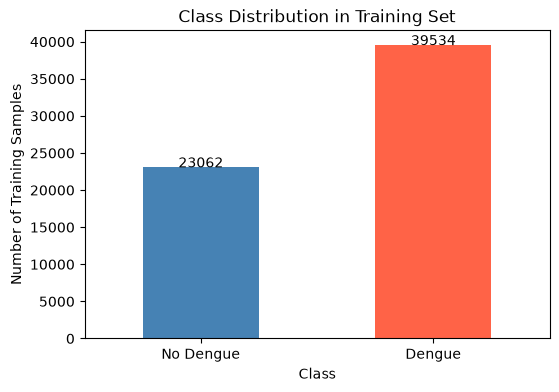

In [97]:
class_counts = Y_train.value_counts().sort_index()

ax = class_counts.plot(
    kind="bar",
    figsize=(6,4),
    color=["steelblue", "tomato"]
)

ax.set_xticklabels(["No Dengue", "Dengue"], rotation=0)

for i, value in enumerate(class_counts):
    plt.text(i, value + 5, str(value), ha="center")

plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Training Samples")
plt.show()

### 6. Model Creation and Training

In [98]:
# Train the Logistic Regression model using the processed training features and target labels
model = LogisticRegression(max_iter=1000,random_state=42)

model.fit(X_train_final, Y_train)


c:\Users\ayxst\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### 7. Validation Evaluation

In [99]:
Y_val_pred = model.predict(X_val_final)
# Predict the probability of each class and extract the probability
# of the positive class (class 1) for each validation sample
Y_val_prob = model.predict_proba(X_val_final)[:, 1]

accuracy = accuracy_score(Y_val, Y_val_pred)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.7959


In [100]:
print(classification_report(Y_val, Y_val_pred))

              precision    recall  f1-score   support

           0       0.74      0.68      0.71      4942
           1       0.82      0.86      0.84      8471

    accuracy                           0.80     13413
   macro avg       0.78      0.77      0.78     13413
weighted avg       0.79      0.80      0.79     13413



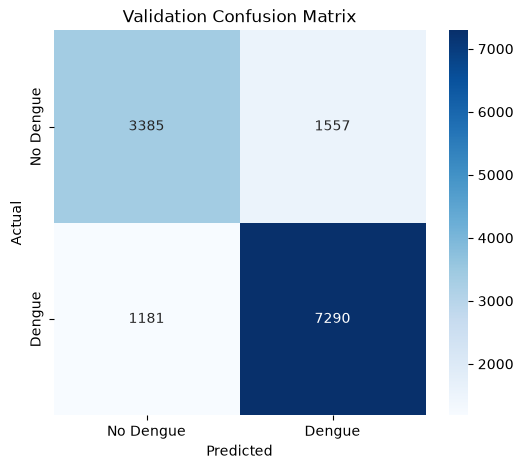

In [101]:
# it computes the confusion matrix by comparing actual and predicted labels
cm_val = confusion_matrix(Y_val, Y_val_pred)
# creates a figure with specified size
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Dengue", "Dengue"],
    yticklabels=["No Dengue", "Dengue"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")

plt.show()

In [102]:
# it calculates the ROC-AUC score using the true labels and the predicted probabilities for the positive class
auc = roc_auc_score(Y_val, Y_val_prob)

print(f"Validation ROC-AUC: {auc:.4f}")

Validation ROC-AUC: 0.8798


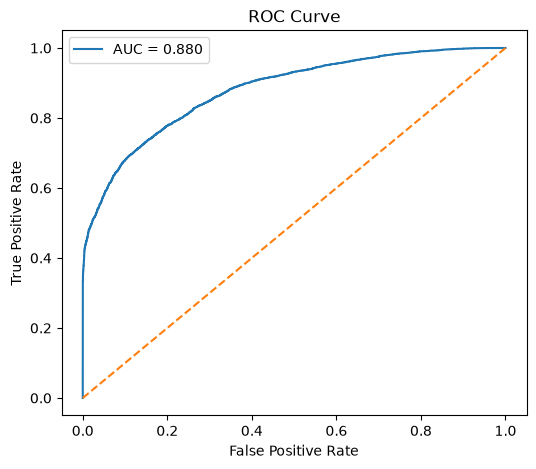

In [103]:
# it calculates the False Positive Rate (FPR), True Positive Rate (TPR), and classification thresholds for the ROC curve
fpr, tpr, thresholds = roc_curve(Y_val, Y_val_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

### 7. Hyperparamater Tuning

In [104]:
# defines the hyperparameter grid to test different combinations of regularization strength (c), penalty type and solver
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}
# creates GridSearchCV object to perform an exhaustive search over the specified hyperparameter combinations
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
# trains model using every hyperparameter combination and identify the best-performing model
grid_search.fit(X_train_final, Y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

c:\Users\ayxst\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ayxst\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation F1 Score: 0.8467235817960459


#### 7.1 Taking the best model

In [105]:
# Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
# Best Cross-Validation F1 Score: 0.8467235817960459
#  retrieves the best-performing logistic regression model
best_model = grid_search.best_estimator_
print(best_model)

LogisticRegression(C=1, max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')


### 8. Final Model Evaluation

#### 8.1 Final Model Evaluation Using Validation Dataset

In [106]:
Y_val_pred_tuned = best_model.predict(X_val_final)
Y_val_prob_tuned = best_model.predict_proba(X_val_final)[:, 1]


print("Validation Accuracy:", accuracy_score(Y_val, Y_val_pred))
print(classification_report(Y_val, Y_val_pred))


Validation Accuracy: 0.7958696786699471
              precision    recall  f1-score   support

           0       0.74      0.68      0.71      4942
           1       0.82      0.86      0.84      8471

    accuracy                           0.80     13413
   macro avg       0.78      0.77      0.78     13413
weighted avg       0.79      0.80      0.79     13413



In [107]:
auc_tuned = roc_auc_score(Y_val, Y_val_prob_tuned)

print(f"Validation ROC-AUC: {auc:.4f}")


Validation ROC-AUC: 0.8798


#### 8.2 Training Vs Validation Curve

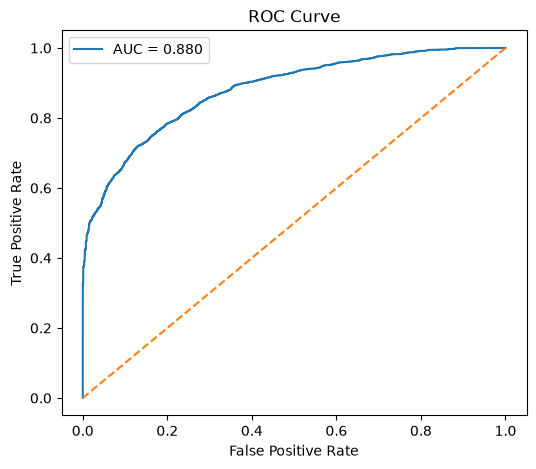

In [108]:

fpr, tpr, thresholds = roc_curve(Y_val, Y_val_prob_tuned)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()


#### 8.3 Final Model Confusion Matrix

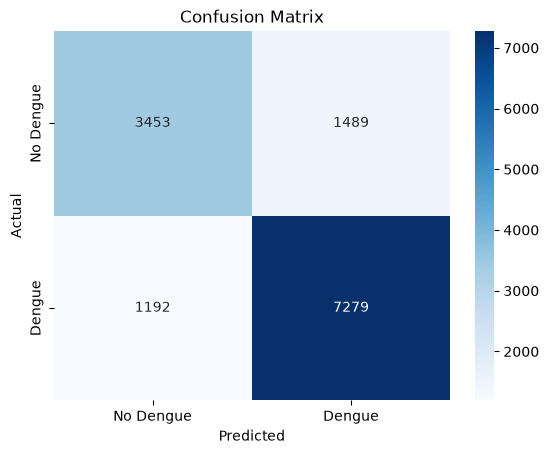

In [109]:
cm_tuned = confusion_matrix(Y_val, Y_val_pred_tuned)

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Dengue', 'Dengue'],
    yticklabels=['No Dengue', 'Dengue']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#### 8.4 Final Model Evaluation Using Validation Dataset

In [110]:
# making prediction using the test data
y_test_pred = best_model.predict(X_test_final)

# classification report of the model based on test data
print(classification_report(Y_test, y_test_pred));

Y_val_prob_tuned = model.predict_proba(X_val_final)[:, 1]


              precision    recall  f1-score   support

           0       0.75      0.70      0.72      4936
           1       0.83      0.86      0.85      8479

    accuracy                           0.80     13415
   macro avg       0.79      0.78      0.78     13415
weighted avg       0.80      0.80      0.80     13415



In [111]:
auc_tuned = roc_auc_score(Y_test, y_test_pred)

print(f"Validation ROC-AUC: {auc:.4f}")


Validation ROC-AUC: 0.8798


#### 8.5 Confusion Matrix for Test Set

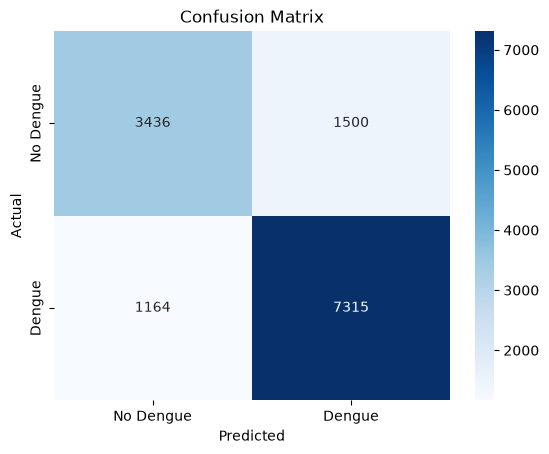

In [112]:
cm_test = confusion_matrix(Y_test, y_test_pred)

sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Dengue', 'Dengue'],
    yticklabels=['No Dengue', 'Dengue']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()